# IDEAL Stage 4: context and temporal stability analysis

This notebook compares daily archetypes across contextual subsets and checks whether the archetype structure is stable across weekday/weekend and season.

## Step 1. Load Stage 1 and Stage 2 outputs

Load the daily feature table, daily archetype labels, and centroid table from the organised output folders.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.vq import kmeans2
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

ROOT = Path.cwd()
if ROOT.name == 'script':
    ROOT = ROOT.parent
SCRIPT_DIR = ROOT / 'script'

STAGE1_DIR = SCRIPT_DIR / 'outputs' / 'stage1_preparation'
STAGE2_DIR = SCRIPT_DIR / 'outputs' / 'stage2_clustering'
STAGE4_DIR = SCRIPT_DIR / 'outputs' / 'stage4_context_analysis'
STAGE4_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR = ROOT / 'metadata_and_surveys (1)' / 'metadata'
SENSORDATA_DIR = ROOT / 'sensordata'

daily_features = pd.read_csv(STAGE1_DIR / 'daily_electricity_features_enhanced.csv', low_memory=False)
daily_archetypes = pd.read_csv(STAGE2_DIR / 'daily_archetypes_enhanced.csv', low_memory=False)
centroids_df = pd.read_csv(STAGE2_DIR / 'daily_archetype_centroids_enhanced.csv', low_memory=False)

daily_features['date'] = pd.to_datetime(daily_features['date'], errors='coerce')
daily_archetypes['date'] = pd.to_datetime(daily_archetypes['date'], errors='coerce')

NORM_COLS = sorted([c for c in daily_features.columns if c.startswith('norm_block_')], key=lambda c: int(c.replace('norm_block_', '')))
PLOT_HOURS = [int(c.replace('norm_block_', '')) for c in NORM_COLS]

print(daily_features.shape)
print(daily_archetypes.shape)
centroids_df.head()

(12147, 105)
(9251, 108)


,daily_archetype,archetype_name,pattern_note,norm_block_00,norm_block_02,norm_block_04,norm_block_06,norm_block_08,norm_block_10,norm_block_12,norm_block_14,norm_block_16,norm_block_18,norm_block_20,norm_block_22
0,0,Morning peak,broad daytime-elevated profile,0.101687,0.047599,0.079029,0.153103,0.565133,0.442879,0.282536,0.179744,0.156588,0.198899,0.217214,0.204592
1,1,All-daytime plateau,broad plateau profile,0.112901,0.050914,0.063500,0.253197,0.401061,0.517918,0.611148,0.592258,0.588973,0.607982,0.550582,0.296525
2,2,Evening peak,broad evening-focused profile,0.090041,0.050053,0.092833,0.226632,0.156744,0.106633,0.098902,0.117767,0.252915,0.796836,0.667885,0.320767
3,3,Late-afternoon peak,narrow-peak subtype,0.062084,0.039564,0.114893,0.233522,0.197271,0.146830,0.151854,0.251095,0.942031,0.528074,0.362335,0.166104
4,4,Early-morning peak,narrow-peak subtype,0.064327,0.043394,0.132487,0.943309,0.229871,0.092935,0.096578,0.108651,0.202409,0.320718,0.346720,0.195609


## Step 2. Define contextual subsets

Restrict seasonal comparison to Winter and Summer, then combine this with weekday/weekend to create four contexts.

In [23]:
daily_features['season_simple'] = daily_features['season'].where(daily_features['season'].isin(['Winter', 'Summer']))
daily_features['daytype_simple'] = np.where(daily_features['is_weekend'].fillna(False), 'Weekend', 'Weekday')
daily_features['context'] = np.where(
    daily_features['season_simple'].notna(),
    daily_features['season_simple'] + '_' + daily_features['daytype_simple'],
    pd.NA,
)

daily_archetypes['season_simple'] = daily_archetypes['season'].where(daily_archetypes['season'].isin(['Winter', 'Summer']))
daily_archetypes['daytype_simple'] = np.where(daily_archetypes['is_weekend'].fillna(False), 'Weekend', 'Weekday')
daily_archetypes['context'] = np.where(
    daily_archetypes['season_simple'].notna(),
    daily_archetypes['season_simple'] + '_' + daily_archetypes['daytype_simple'],
    pd.NA,
)

context_counts = daily_archetypes['context'].value_counts(dropna=True).rename_axis('context').reset_index(name='n_days')
context_counts

,context,n_days
0,Winter_Weekday,1860
1,Summer_Weekday,1260
2,Winter_Weekend,783
3,Summer_Weekend,537


## Step 3. Compare Stage 2 archetype distribution across contexts

Before re-clustering, compare how the existing Stage 2 archetypes are distributed across Winter/Summer and Weekday/Weekend contexts.

In [24]:
context_distribution = (
    daily_archetypes.assign(day_count=1)
    .pivot_table(index='context', columns='archetype_name', values='day_count', aggfunc='sum', fill_value=0)
    .reset_index()
)
archetype_cols = [c for c in context_distribution.columns if c != 'context']
context_distribution[archetype_cols] = context_distribution[archetype_cols].div(context_distribution[archetype_cols].sum(axis=1), axis=0)
context_distribution

archetype_name,context,All-daytime plateau,Early-morning peak,Evening peak,Late-afternoon peak,Morning peak
0,Summer_Weekday,0.119841,0.206349,0.313492,0.189683,0.170635
1,Summer_Weekend,0.225326,0.100559,0.229050,0.169460,0.275605
2,Winter_Weekday,0.212366,0.150000,0.356452,0.133333,0.147849
3,Winter_Weekend,0.344828,0.015326,0.252874,0.167305,0.219668


## Step 4. Plot contextual archetype mix

This plot shows how the existing Stage 2 archetypes shift across the four contexts.

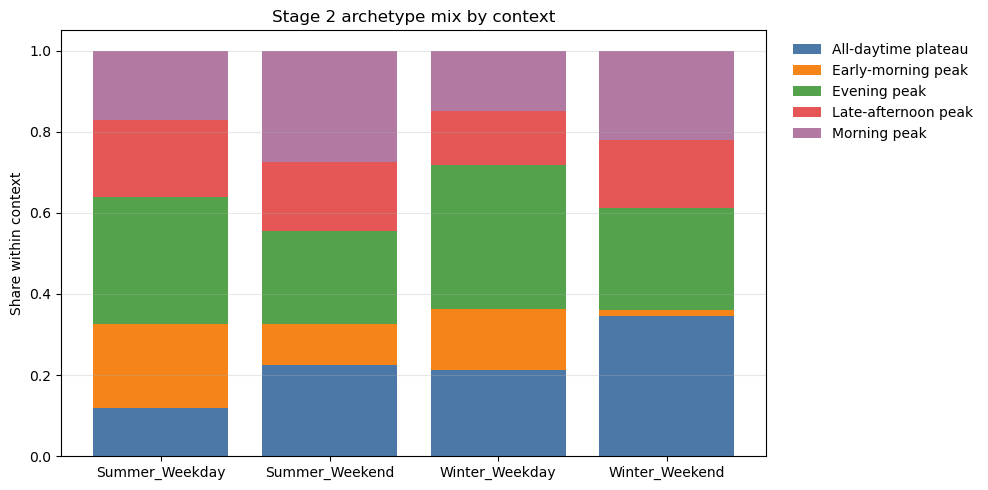

In [25]:
fig_mix, ax_mix = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(context_distribution))
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#B279A2']
for col, color in zip(archetype_cols, colors):
    ax_mix.bar(context_distribution['context'], context_distribution[col], bottom=bottom, label=col, color=color)
    bottom = bottom + context_distribution[col].to_numpy()
ax_mix.set_ylabel('Share within context')
ax_mix.set_title('Stage 2 archetype mix by context')
ax_mix.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
ax_mix.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5. Re-cluster each context using k=5

Run a separate k-means model inside each context on the normalised daily load profiles to check whether centroid shapes remain similar.

In [26]:
CONTEXTS = ['Winter_Weekday', 'Winter_Weekend', 'Summer_Weekday', 'Summer_Weekend']
SELECTED_K = 5

context_cluster_tables = []
context_centroid_tables = []

for context in CONTEXTS:
    subset = daily_features[(daily_features['context'] == context) & (daily_features['cluster_ready_day'].fillna(False))].copy()
    subset = subset[subset[NORM_COLS].notna().all(axis=1)].reset_index(drop=True)
    if len(subset) < SELECTED_K:
        continue

    X = subset[NORM_COLS].to_numpy(dtype=float)
    np.random.seed(42)
    centroids, labels = kmeans2(X, SELECTED_K, minit='points', iter=100)

    order = np.argsort([int(np.argmax(c)) for c in centroids])
    remap = {old: new for new, old in enumerate(order)}
    ordered_centroids = centroids[order]
    ordered_labels = np.array([remap[l] for l in labels])

    subset['context_cluster'] = ordered_labels
    subset['context'] = context
    context_cluster_tables.append(subset[['homeid', 'date', 'context', 'context_cluster'] + NORM_COLS])

    centroid_df = pd.DataFrame(ordered_centroids, columns=NORM_COLS)
    centroid_df.insert(0, 'context_cluster', range(len(ordered_centroids)))
    centroid_df.insert(0, 'context', context)
    context_centroid_tables.append(centroid_df)

context_cluster_df = pd.concat(context_cluster_tables, ignore_index=True)
context_centroid_df = pd.concat(context_centroid_tables, ignore_index=True)

print(context_cluster_df.shape)
context_centroid_df.head()

(4440, 16)


,context,context_cluster,norm_block_00,norm_block_02,norm_block_04,norm_block_06,norm_block_08,norm_block_10,norm_block_12,norm_block_14,norm_block_16,norm_block_18,norm_block_20,norm_block_22
0,Winter_Weekday,0,0.098160,0.046574,0.067478,0.670744,0.517362,0.105187,0.082557,0.097007,0.136029,0.248602,0.350897,0.314647
1,Winter_Weekday,1,0.108936,0.054196,0.034417,0.130086,0.287208,0.602730,0.540052,0.342488,0.254384,0.298906,0.282390,0.224691
2,Winter_Weekday,2,0.095359,0.043895,0.046392,0.249989,0.178047,0.148755,0.217374,0.339210,0.875415,0.621150,0.450015,0.279534
3,Winter_Weekday,3,0.109031,0.046554,0.053149,0.294046,0.139430,0.082632,0.086719,0.092965,0.216799,0.810527,0.670362,0.381044
4,Winter_Weekday,4,0.146873,0.059621,0.059020,0.317084,0.650538,0.529298,0.513712,0.450916,0.640259,0.704826,0.665996,0.387438


## Step 6. Plot re-clustered context centroids

Inspect whether the within-context centroids resemble the main Stage 2 archetypes or become substantially different.

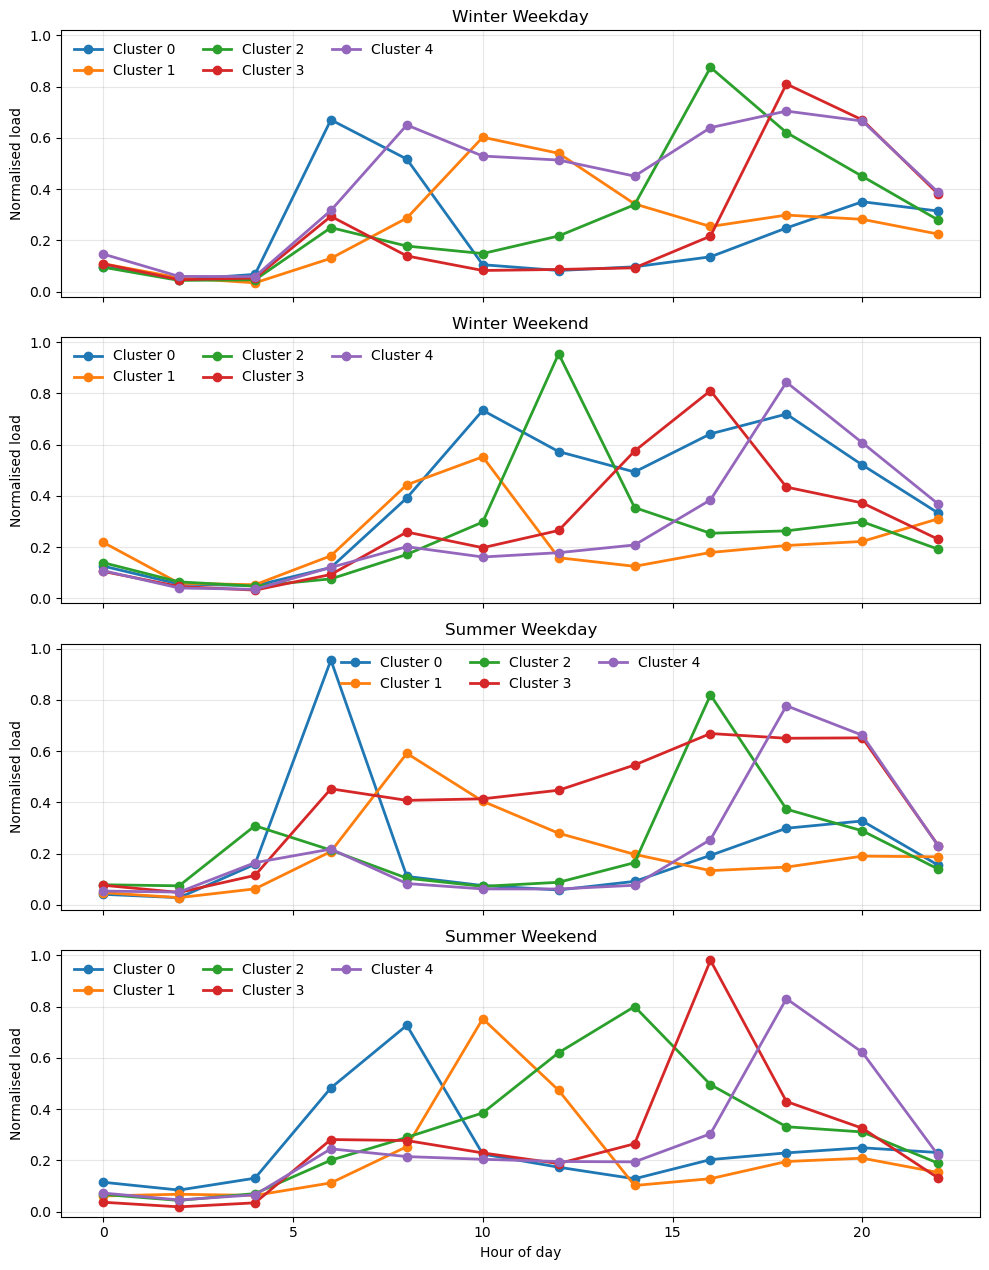

In [27]:
fig_ctx, axes = plt.subplots(len(CONTEXTS), 1, figsize=(10, 3.2 * len(CONTEXTS)), sharex=True)
if len(CONTEXTS) == 1:
    axes = [axes]

for ax, context in zip(axes, CONTEXTS):
    subset = context_centroid_df[context_centroid_df['context'] == context]
    for _, row in subset.iterrows():
        ax.plot(PLOT_HOURS, row[NORM_COLS].to_numpy(dtype=float), marker='o', linewidth=2, label=f"Cluster {int(row['context_cluster'])}")
    ax.set_title(context.replace('_', ' '))
    ax.set_ylabel('Normalised load')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, ncol=3)

axes[-1].set_xlabel('Hour of day')
plt.tight_layout()
plt.show()

## Step 7. Map context clusters to Stage 2 archetypes

Use correlation distance between centroids so each within-context cluster can be matched to the nearest Stage 2 archetype shape.

In [28]:
stage2_reference = centroids_df[['daily_archetype', 'archetype_name'] + NORM_COLS].copy()
mapping_rows = []
for context in CONTEXTS:
    ctx = context_centroid_df[context_centroid_df['context'] == context].reset_index(drop=True)
    if ctx.empty:
        continue
    distances = cdist(ctx[NORM_COLS].to_numpy(dtype=float), stage2_reference[NORM_COLS].to_numpy(dtype=float), metric='correlation')
    nearest_idx = distances.argmin(axis=1)
    for row_idx, stage2_idx in enumerate(nearest_idx):
        mapping_rows.append({
            'context': context,
            'context_cluster': int(ctx.loc[row_idx, 'context_cluster']),
            'nearest_stage2_archetype': int(stage2_reference.loc[stage2_idx, 'daily_archetype']),
            'nearest_stage2_name': stage2_reference.loc[stage2_idx, 'archetype_name'],
            'correlation_distance': float(distances[row_idx, stage2_idx]),
        })

context_cluster_mapping = pd.DataFrame(mapping_rows).sort_values(['context', 'context_cluster']).reset_index(drop=True)
context_cluster_mapping


,context,context_cluster,nearest_stage2_archetype,nearest_stage2_name,correlation_distance
0,Summer_Weekday,0,4,Early-morning peak,0.009255
1,Summer_Weekday,1,0,Morning peak,0.019691
2,Summer_Weekday,2,3,Late-afternoon peak,0.064438
3,Summer_Weekday,3,1,All-daytime plateau,0.095657
4,Summer_Weekday,4,2,Evening peak,0.014525
5,Summer_Weekend,0,0,Morning peak,0.306319
6,Summer_Weekend,1,0,Morning peak,0.310792
7,Summer_Weekend,2,1,All-daytime plateau,0.152022
8,Summer_Weekend,3,3,Late-afternoon peak,0.026402
9,Summer_Weekend,4,2,Evening peak,0.032615


## Step 8. Build date-level temperature-prevalence input

Use daily mean temperature from the Edinburgh weather feed as a common proxy and aggregate archetype prevalence across all observed homes on each date.

In [29]:
weather = pd.read_csv(SENSORDATA_DIR / 'weatherreading.csv.gz', low_memory=False)
weather['time'] = pd.to_datetime(weather['time'], errors='coerce')
weather['date'] = weather['time'].dt.floor('D')
weather['value_num'] = pd.to_numeric(weather['value'], errors='coerce')

edinburgh_temp = weather[weather['feedid'] == 1].copy()
edinburgh_temp['temperature_c'] = edinburgh_temp['value_num'] / 10.0
edinburgh_daily_temp = edinburgh_temp.groupby('date')['temperature_c'].mean().reset_index()

daily_total = daily_archetypes.groupby('date').size().rename('n_homes_total').reset_index()
daily_prev = daily_archetypes.groupby(['date', 'archetype_name']).size().rename('n_homes_this_arch').reset_index()
temp_prevalence = daily_prev.merge(daily_total, on='date', how='left').merge(edinburgh_daily_temp, on='date', how='left')
temp_prevalence['archetype_prevalence'] = temp_prevalence['n_homes_this_arch'] / temp_prevalence['n_homes_total']
temp_prevalence = temp_prevalence.dropna(subset=['temperature_c']).reset_index(drop=True)

corr_rows = []
for archetype_name in ['Morning peak', 'All-daytime plateau', 'Evening peak', 'Late-afternoon peak', 'Early-morning peak']:
    subset = temp_prevalence[temp_prevalence['archetype_name'] == archetype_name].copy()
    rho, pval = spearmanr(subset['temperature_c'], subset['archetype_prevalence'], nan_policy='omit')
    corr_rows.append({'archetype_name': archetype_name, 'n_days': len(subset), 'spearman_rho': float(rho), 'p_value': float(pval)})
temperature_corr_df = pd.DataFrame(corr_rows)
temperature_corr_df


,archetype_name,n_days,spearman_rho,p_value
0,Morning peak,466,0.067241,1.472576e-01
1,All-daytime plateau,441,-0.314436,1.413180e-11
2,Evening peak,568,-0.085414,4.186208e-02
3,Late-afternoon peak,476,0.147878,1.213677e-03
4,Early-morning peak,463,0.100545,3.053354e-02


## Step 9. Plot temperature-prevalence relationships

Plot date-level prevalence against temperature and overlay a LOWESS trend line for each archetype.

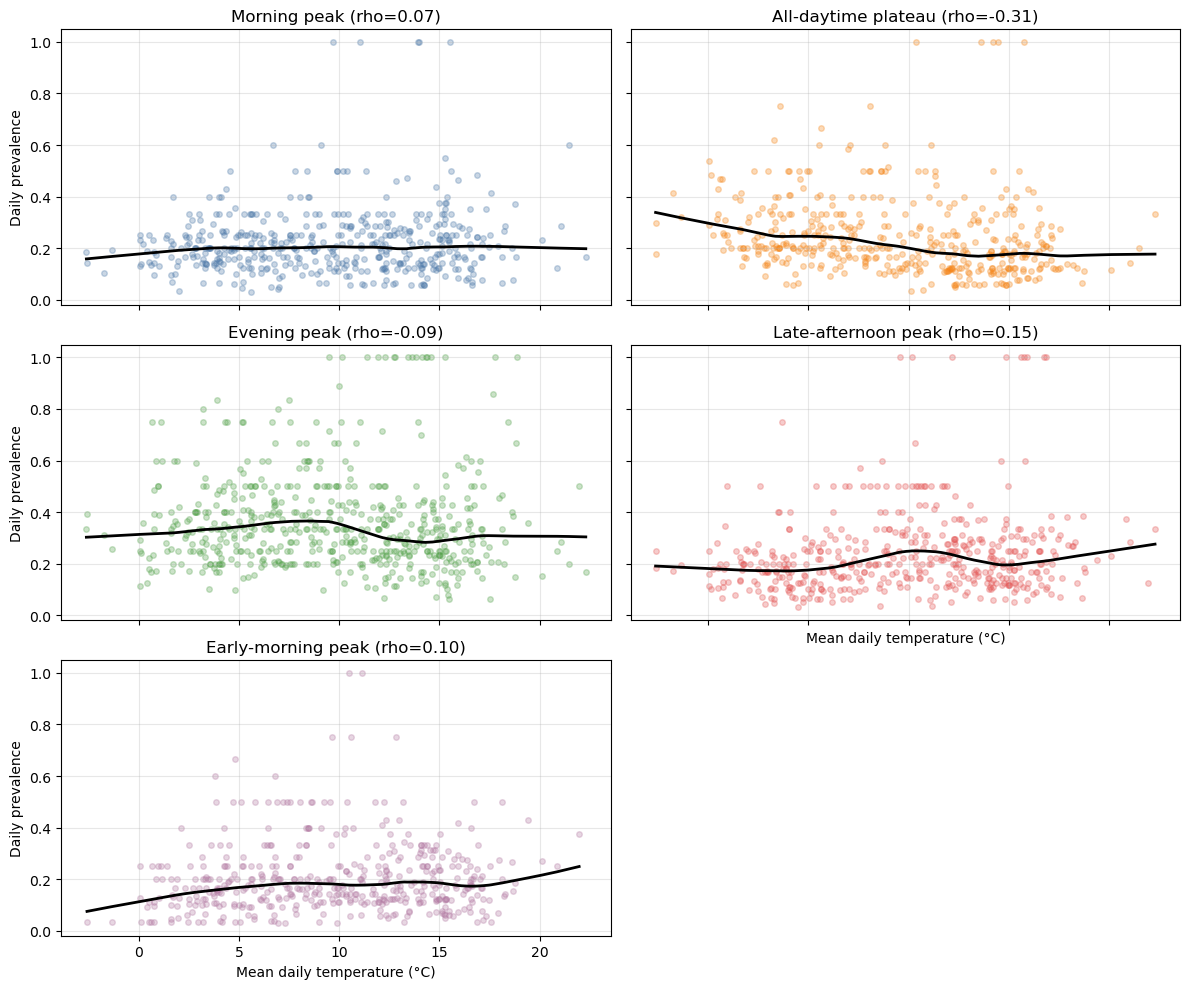

In [30]:
ARCHETYPE_ORDER = ['Morning peak', 'All-daytime plateau', 'Evening peak', 'Late-afternoon peak', 'Early-morning peak']
color_map = {
    'Morning peak': '#4C78A8',
    'All-daytime plateau': '#F58518',
    'Evening peak': '#54A24B',
    'Late-afternoon peak': '#E45756',
    'Early-morning peak': '#B279A2',
}
fig_temp, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()
for ax, archetype_name in zip(axes, ARCHETYPE_ORDER):
    subset = temp_prevalence[temp_prevalence['archetype_name'] == archetype_name].copy().sort_values('temperature_c')
    ax.scatter(subset['temperature_c'], subset['archetype_prevalence'], alpha=0.30, s=16, color=color_map[archetype_name])
    if len(subset) > 10:
        smooth = lowess(subset['archetype_prevalence'], subset['temperature_c'], frac=0.35, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], color='black', linewidth=2)
    row = temperature_corr_df[temperature_corr_df['archetype_name'] == archetype_name].iloc[0]
    ax.set_title(f"{archetype_name} (rho={row['spearman_rho']:.2f})")
    ax.grid(alpha=0.3)
for ax in axes[len(ARCHETYPE_ORDER):]:
    ax.axis('off')
axes[0].set_ylabel('Daily prevalence')
axes[2].set_ylabel('Daily prevalence')
axes[4].set_ylabel('Daily prevalence')
axes[4].set_xlabel('Mean daily temperature (°C)')
axes[3].set_xlabel('Mean daily temperature (°C)')
plt.tight_layout()
plt.show()


## Step 10. Analyse household switching across contexts

Use the original Stage 2 archetype labels to see whether the same home tends to exhibit a different dominant pattern across Winter/Summer and Weekday/Weekend contexts.

In [31]:
context_modal = (
    daily_archetypes.dropna(subset=['context'])
    .groupby(['homeid', 'context'])['archetype_name']
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else pd.NA)
    .reset_index()
)

context_modal_wide = context_modal.pivot(index='homeid', columns='context', values='archetype_name').reset_index()
context_modal_wide.head()

context,homeid,Summer_Weekday,Summer_Weekend,Winter_Weekday,Winter_Weekend
0,61,Late-afternoon peak,All-daytime plateau,Evening peak,All-daytime plateau
1,62,Evening peak,Morning peak,Evening peak,All-daytime plateau
2,63,Early-morning peak,All-daytime plateau,Early-morning peak,Morning peak
3,65,Evening peak,All-daytime plateau,Evening peak,Evening peak
4,73,Morning peak,Morning peak,Evening peak,Morning peak


## Step 11. Summarise switching counts

Count how often the modal archetype changes across the four contexts for each home.

In [32]:
modal_cols = [c for c in context_modal_wide.columns if c != 'homeid']
context_modal_wide['n_distinct_context_archetypes'] = context_modal_wide[modal_cols].nunique(axis=1, dropna=True)
switching_summary = context_modal_wide['n_distinct_context_archetypes'].value_counts().sort_index().rename_axis('n_distinct_context_archetypes').reset_index(name='n_homes')
switching_summary

,n_distinct_context_archetypes,n_homes
0,1,8
1,2,19
2,3,12


## Step 12. Save Stage 4 outputs

Save the context comparison tables and figures for reporting and discussion.

In [33]:
context_distribution.to_csv(STAGE4_DIR / 'context_archetype_distribution_enhanced.csv', index=False)
context_cluster_df.to_csv(STAGE4_DIR / 'context_reclustered_days_enhanced.csv', index=False)
context_centroid_df.to_csv(STAGE4_DIR / 'context_reclustered_centroids_enhanced.csv', index=False)
context_cluster_mapping.to_csv(STAGE4_DIR / 'context_cluster_mapping_enhanced.csv', index=False)
temp_prevalence.to_csv(STAGE4_DIR / 'temperature_archetype_prevalence_enhanced.csv', index=False)
temperature_corr_df.to_csv(STAGE4_DIR / 'temperature_archetype_correlation_summary_enhanced.csv', index=False)
context_modal_wide.to_csv(STAGE4_DIR / 'household_context_modal_archetypes_enhanced.csv', index=False)
switching_summary.to_csv(STAGE4_DIR / 'household_context_switching_summary_enhanced.csv', index=False)

fig_mix.savefig(STAGE4_DIR / 'context_archetype_mix_enhanced.png', dpi=200, bbox_inches='tight')
fig_ctx.savefig(STAGE4_DIR / 'context_reclustered_centroids_enhanced.png', dpi=200, bbox_inches='tight')
fig_temp.savefig(STAGE4_DIR / 'temperature_archetype_prevalence_enhanced.png', dpi=200, bbox_inches='tight')

print('Saved Stage 4 outputs to:', STAGE4_DIR)


Saved Stage 4 outputs to: /Users/hlbao/Desktop/benv0145/IDEAL/script/outputs/stage4_context_analysis
